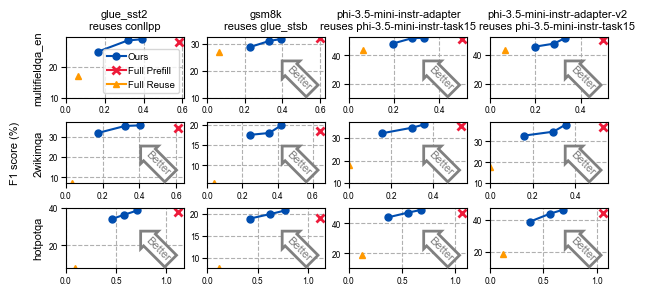

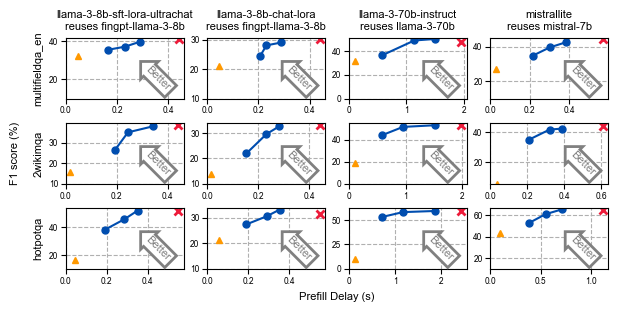

2.8847733955062247 2.1326652698626845 3.4878314560724966
14.090249999999997 1.7699999999999996 42.81999999999999


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

font_sz = 8
font = "Arial"

colors = [
    '#004DAF', # blue
    '#ED1B3A', # red
    '#FF9900', # yellow
    '#33A02C', # green
    '#FABEAF', # pink
    '#AAD59B', # light green
    '#FC5A50',
    "#008080",
    "#0000FF",
    "#808000",
    "#800080"
]

axis_font_opt = {
    "fontsize": font_sz,
    "fontfamily": font
}
title_font_opt = {
    "fontsize": font_sz+2,
    "fontfamily": font
}

plt.rcParams['font.family'] = font
plt.rcParams['font.size'] = font_sz

model_pairs_group1 = {
    "conllpp": [
        "glue_sst2",
    ],
    "glue_stsb": ["gsm8k"],
    "phi-3-5-mini-instr-task15": [
        "phi-3-5-mini-instr-adapter",
        "phi-3-5-mini-instr-adapter-v2",
    ],
}

model_pairs_group2 = {
    "fingpt-llama-3-8b": [
        "llama-3-8b-sft-lora-ultrachat",
        "llama-3-8b-chat-lora",
    ],
    "llama-3.1-70b": ["llama-3.1-70b-instruct"],
    "mistral-7b": ["mistrallite"],
}

datasets = [
    "multifieldqa_en",
    "2wikimqa",
    "hotpotqa"
]

delay_reduction_arr = []
acc_improv_arr = []

def plot_group(model_pairs_group, datasets, group_idx):

    global delay_reduction_arr
    global acc_improv_arr

    df = pd.read_csv("./data.tsv", delimiter=" ")
    ncols = 4
    nrows = len(datasets)
    _, axes = plt.subplots(nrows, ncols, figsize=(7, 1 * nrows))

    for row in range(len(datasets)):
        dataset = datasets[row]
        i = 0
        for base_model, models in model_pairs_group.items():
            for model in models:
                col = i % ncols
                i += 1
                ax = axes[row][col]

                cur_exp_df = df.query(
                    f"base_model == '{base_model}' and model == '{model}' and dataset == '{dataset}'")
                ours = cur_exp_df.query("type == 0")
                full_prefill = cur_exp_df.query("type == 1")
                full_kv = cur_exp_df.query("type == 2")

                ours_optimal = ours.sort_values("prefill").iloc[0]
                delay_reduction_arr.append((full_prefill["prefill"] / ours_optimal["prefill"]).item())
                acc_improv_arr.append((ours_optimal["acc"] - full_kv["acc"]).item())

                ax.plot(
                    ours["prefill"], ours["acc"],
                    linestyle="-",
                    marker="o",
                    label="Ours",
                    color='#004DAF',
                    markersize=5
                )
                ax.plot(
                    full_prefill["prefill"],
                    full_prefill["acc"],
                    marker="x",
                    label="Full Prefill",
                    markeredgewidth=2,
                    color='#ED1B3A'
                )
                ax.plot(
                    full_kv["prefill"],
                    full_kv["acc"],
                    marker="^",
                    label="Full Reuse",
                    color='#FF9900',
                    markersize=5
                )

                ax.grid(linestyle='--')

                if col == 0:
                    if row == int(len(datasets) / 2):
                        ax.set_ylabel(f"F1 score (%)\n\n{dataset}", fontsize=font_sz)
                    else:
                        ax.set_ylabel(dataset, fontsize=font_sz)

                if row == 0 and col == 0 and group_idx == 1:
                    ax.legend(fontsize=font_sz-1, handletextpad=0.2, loc="lower right")
                else:
                    # Add an arrow annotation
                    bbox_props = dict(boxstyle="larrow", fc=(1,1,1), ec="grey", lw=2)
                    ax.text(0.9, 0.1, "Better", ha="right", 
                        va="bottom", rotation=-45, bbox=bbox_props, c='grey',
                        transform=ax.transAxes
                    )

                if row == 0:
                    title = f"{model}\nreuses {base_model}".replace("3-5", "3.5")
                    if model == "phi-3-5-mini-instr-adapter":
                        ax.set_title(title, fontsize=font_sz, x=0.42)
                    elif model == "phi-3-5-mini-instr-adapter-v2":
                        ax.set_title(title, fontsize=font_sz, x=0.57)
                    else:
                        ax.set_title(title, fontsize=font_sz)

                if row == len(datasets) - 1 and col == 0 and group_idx==2:
                    ax.set_xlabel("Prefill Delay (s)", fontsize=font_sz)
                    ax.xaxis.set_label_coords(2.3, -0.38)

                ax.tick_params(axis="both", which="major",
                               labelsize=font_sz - 2, pad=2)
                ax.set_xlim(left=0)
                if model == "llama-3-70b-instruct":
                    ax.set_ylim(bottom=0)
                else:
                    ax.set_ylim(bottom=min(10, full_kv.iloc[0]['acc']))


    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    plt.savefig(f"overall-{group_idx}.pdf", bbox_inches="tight")
    plt.show()

plot_group(model_pairs_group1, datasets, 1)
plot_group(model_pairs_group2, datasets, 2)

delay_reduction_arr = np.array(delay_reduction_arr)
delay_reduction_arr = np.where(np.isinf(delay_reduction_arr), np.nan, delay_reduction_arr)

acc_improv_arr = np.array(acc_improv_arr)
acc_improv_arr = np.where(np.isinf(acc_improv_arr), np.nan, acc_improv_arr)

print(np.nanmean(delay_reduction_arr), np.nanmin(delay_reduction_arr), np.nanmax(delay_reduction_arr))
print(np.nanmean(acc_improv_arr), np.nanmin(acc_improv_arr), np.nanmax(acc_improv_arr))
